# Credit Scoring — EDA v2 (simplified feature pipeline)

**Goal**: explain, feature by feature and with diagrams, what `scripts/preprocess-v2.py` computes.

`preprocess-v2.py` is a **simplified** version of `preprocess.py`: instead of ~15 hand-engineered
ratios on the main table and 5-10 aggregated stats per supplementary table, it keeps only a
handful of the most informative ones per table. This notebook walks through each function of
`preprocess-v2.py` in order, shows what each feature looks like, and checks whether it still
separates defaulters (`TARGET = 1`) from non-defaulters (`TARGET = 0`).

Dataset: [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk).


<a id='1'></a>
## 1. Imports & setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline

DATA_PATH = '../../data/'

# The 5 supplementary tables are large (150-700 MB each). For this notebook we only need
# enough rows to show realistic distributions and diagrams, so we sample them on read.
# The real pipeline (scripts/preprocess-v2.py) always processes the full files.
SAMPLE_ROWS = 300_000

print('Setup complete.')


Setup complete.


<a id='2'></a>
## 2. Load data

Main table in full (needed to join `TARGET`), supplementary tables sampled for speed.

In [2]:
train = pd.read_csv(DATA_PATH + 'application_train.csv')
bureau = pd.read_csv(DATA_PATH + 'bureau.csv', nrows=SAMPLE_ROWS)
prev = pd.read_csv(DATA_PATH + 'previous_application.csv', nrows=SAMPLE_ROWS)
pos = pd.read_csv(DATA_PATH + 'POS_CASH_balance.csv', nrows=SAMPLE_ROWS)
cc = pd.read_csv(DATA_PATH + 'credit_card_balance.csv', nrows=SAMPLE_ROWS)
inst = pd.read_csv(DATA_PATH + 'installments_payments.csv', nrows=SAMPLE_ROWS)

print(f'application_train      : {train.shape}')
print(f'bureau (sampled)       : {bureau.shape}')
print(f'previous_application   : {prev.shape}')
print(f'POS_CASH_balance       : {pos.shape}')
print(f'credit_card_balance    : {cc.shape}')
print(f'installments_payments  : {inst.shape}')


application_train      : (307511, 122)
bureau (sampled)       : (300000, 17)
previous_application   : (300000, 37)
POS_CASH_balance       : (300000, 8)
credit_card_balance    : (300000, 23)
installments_payments  : (300000, 8)


<a id='3'></a>
## 3. Pipeline overview

`preprocess-v2.py` turns 6 raw tables into one feature per `SK_ID_CURR` (client), joined on the main table.

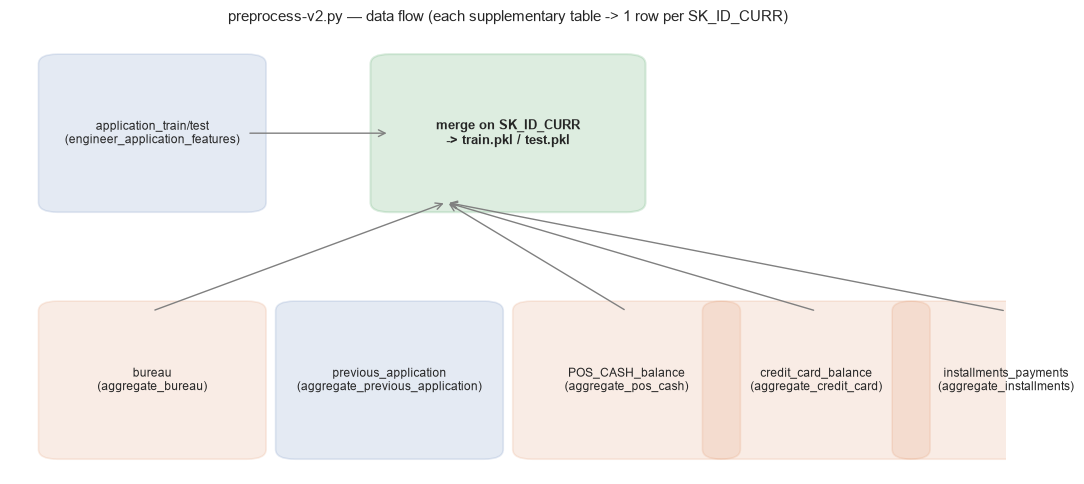

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis('off')

boxes = {
    'application_train/test\n(engineer_application_features)': (0.05, 0.55),
    'bureau\n(aggregate_bureau)': (0.05, 0.05),
    'previous_application\n(aggregate_previous_application)': (0.30, 0.05),
    'POS_CASH_balance\n(aggregate_pos_cash)': (0.55, 0.05),
    'credit_card_balance\n(aggregate_credit_card)': (0.75, 0.05),
    'installments_payments\n(aggregate_installments)': (0.95, 0.05),
}
width, height = 0.20, 0.28

for label, (x, y) in boxes.items():
    color = '#4C72B0' if 'application' in label else '#DD8452'
    ax.add_patch(mpatches.FancyBboxPatch((x, y), width, height,
                 boxstyle='round,pad=0.02', linewidth=1.2,
                 edgecolor=color, facecolor=color, alpha=0.15))
    ax.text(x + width / 2, y + height / 2, label, ha='center', va='center', fontsize=8.5, wrap=True)

merge_x, merge_y = 0.40, 0.55
ax.add_patch(mpatches.FancyBboxPatch((merge_x, merge_y), 0.25, height,
             boxstyle='round,pad=0.02', linewidth=1.5,
             edgecolor='#55A868', facecolor='#55A868', alpha=0.2))
ax.text(merge_x + 0.125, merge_y + height / 2, 'merge on SK_ID_CURR\n-> train.pkl / test.pkl',
        ha='center', va='center', fontsize=9, fontweight='bold')

for label, (x, y) in boxes.items():
    if 'application' in label:
        continue
    ax.annotate('', xy=(merge_x + 0.06, merge_y), xytext=(x + width / 2, y + height),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax.annotate('', xy=(merge_x, merge_y + height / 2), xytext=(0.05 + width, 0.55 + height / 2),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 0.9)
ax.set_title('preprocess-v2.py — data flow (each supplementary table -> 1 row per SK_ID_CURR)', fontsize=11)
plt.tight_layout()
plt.show()


<a id='4'></a>
## 4. `engineer_application_features` — main table ratios

Kept features (out of the ~15 in `preprocess.py`):

| Feature | Formula | Why it matters |
|---|---|---|
| `AGE_YEARS` | `-DAYS_BIRTH / 365` | age is a classic risk driver (younger clients default more) |
| `CREDIT_INCOME_RATIO` | `AMT_CREDIT / AMT_INCOME_TOTAL` | how many years of income the loan represents — leverage |
| `ANNUITY_INCOME_RATIO` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | share of income eaten by the monthly payment — debt burden |
| `EXT_SOURCE_MEAN` | `mean(EXT_SOURCE_1, 2, 3)` | average of 3 external credit-bureau scores — historically the single strongest predictor in this dataset |


In [4]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

train['AGE_YEARS'] = -train['DAYS_BIRTH'] / 365
train['CREDIT_INCOME_RATIO'] = train['AMT_CREDIT'] / train['AMT_INCOME_TOTAL']
train['ANNUITY_INCOME_RATIO'] = train['AMT_ANNUITY'] / train['AMT_INCOME_TOTAL']
train['EXT_SOURCE_MEAN'] = train[ext_cols].mean(axis=1)

app_features = ['AGE_YEARS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'EXT_SOURCE_MEAN']
train[app_features].describe()


,AGE_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EXT_SOURCE_MEAN
count,307511.0000,307511.0000,307499.0000,307339.0000
mean,43.9370,3.9576,0.1809,0.5093
std,11.9561,2.6897,0.0946,0.1498
min,20.5178,0.0048,0.0002,0.0000
25%,34.0082,2.0187,0.1148,0.4136
50%,43.1507,3.2651,0.1628,0.5245
75%,53.9233,5.1599,0.2291,0.6228
max,69.1205,84.7368,1.8760,0.8789


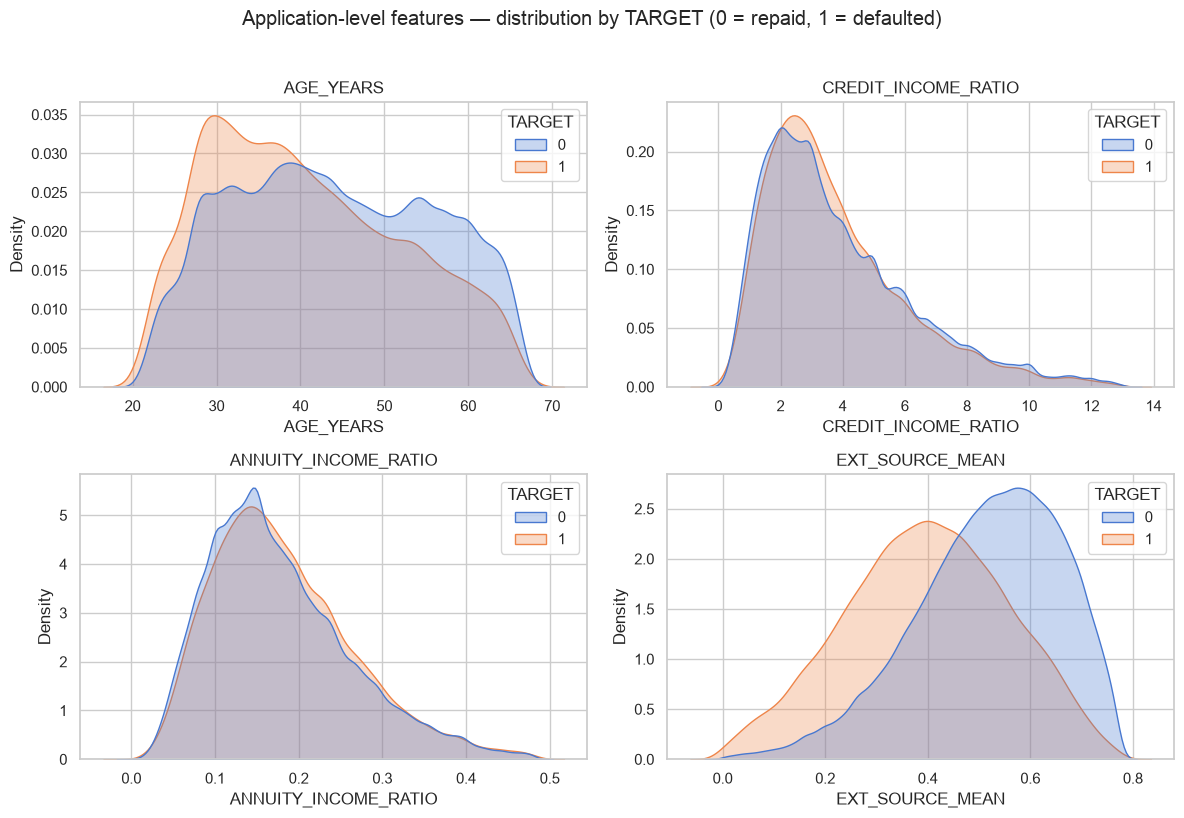

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feat in zip(axes.flat, app_features):
    clip = train[feat].quantile(0.99)
    data = train[train[feat] <= clip]
    sns.kdeplot(data=data, x=feat, hue='TARGET', common_norm=False, fill=True, alpha=0.3, ax=ax)
    ax.set_title(feat)

plt.suptitle('Application-level features — distribution by TARGET (0 = repaid, 1 = defaulted)', y=1.02)
plt.tight_layout()
plt.show()


<a id='5'></a>
## 5. `aggregate_bureau` — credit bureau history

Kept: `BUREAU_AMT_CREDIT_SUM_MEAN`, `BUREAU_AMT_CREDIT_SUM_DEBT_MEAN`, `BUREAU_CREDIT_DAY_OVERDUE_MEAN`, `BUREAU_COUNT` (number of bureau-reported credits per client).

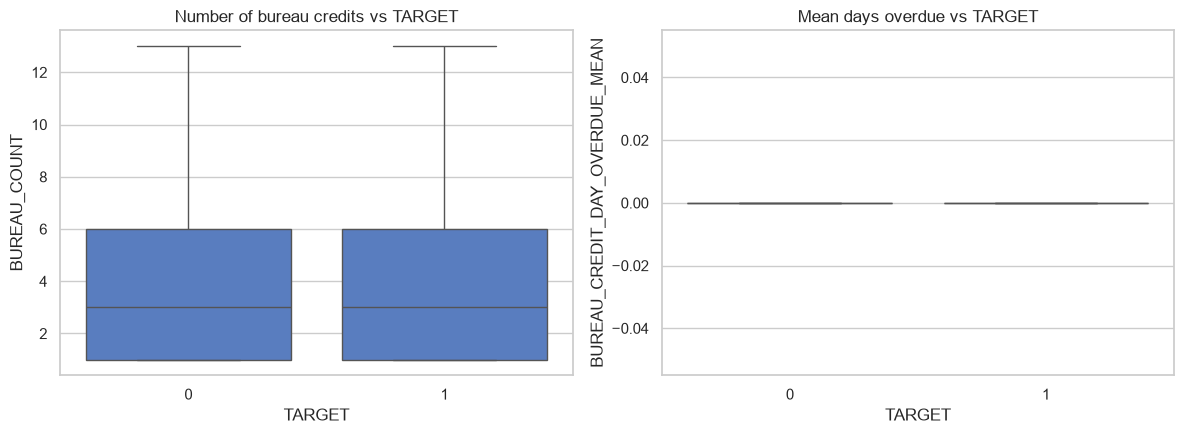

In [6]:
num_agg = {
    'AMT_CREDIT_SUM': ['mean'],
    'AMT_CREDIT_SUM_DEBT': ['mean'],
    'CREDIT_DAY_OVERDUE': ['mean'],
}
bureau_agg = bureau.groupby('SK_ID_CURR').agg(num_agg)
bureau_agg.columns = ['BUREAU_' + '_'.join(c).upper() for c in bureau_agg.columns]
bureau_agg['BUREAU_COUNT'] = bureau.groupby('SK_ID_CURR').size()
bureau_agg = bureau_agg.reset_index()

merged = train[['SK_ID_CURR', 'TARGET']].merge(bureau_agg, on='SK_ID_CURR', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=merged, x='TARGET', y='BUREAU_COUNT', ax=axes[0], showfliers=False)
axes[0].set_title('Number of bureau credits vs TARGET')
sns.boxplot(data=merged, x='TARGET', y='BUREAU_CREDIT_DAY_OVERDUE_MEAN', ax=axes[1], showfliers=False)
axes[1].set_title('Mean days overdue vs TARGET')
plt.tight_layout()
plt.show()


<a id='6'></a>
## 6. `aggregate_previous_application` — past Home Credit applications

Kept: `PREV_AMT_CREDIT_MEAN`, `PREV_AMT_ANNUITY_MEAN`, `PREV_DAYS_DECISION_MEAN`, `PREV_COUNT`.

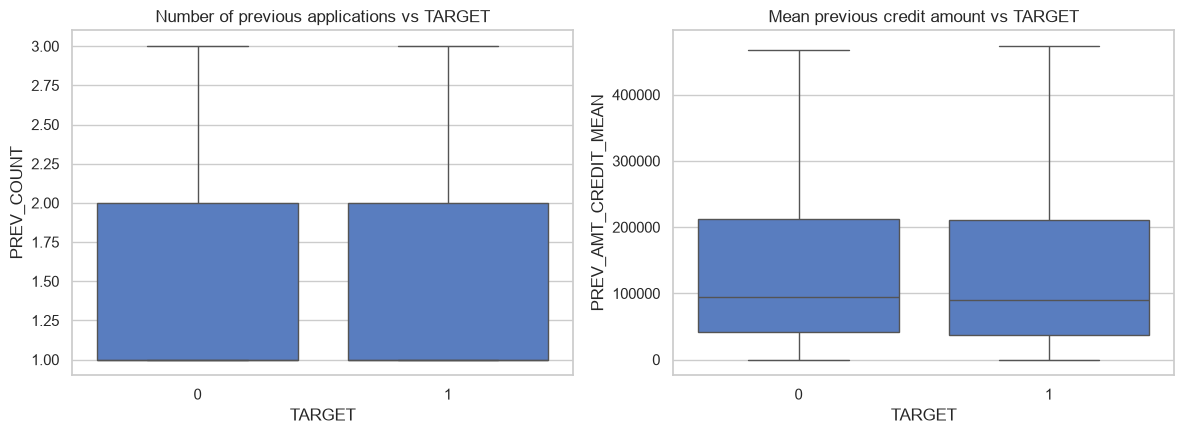

In [7]:
num_agg = {
    'AMT_CREDIT': ['mean'],
    'AMT_ANNUITY': ['mean'],
    'DAYS_DECISION': ['mean'],
}
prev_agg = prev.groupby('SK_ID_CURR').agg(num_agg)
prev_agg.columns = ['PREV_' + '_'.join(c).upper() for c in prev_agg.columns]
prev_agg['PREV_COUNT'] = prev.groupby('SK_ID_CURR').size()
prev_agg = prev_agg.reset_index()

merged = train[['SK_ID_CURR', 'TARGET']].merge(prev_agg, on='SK_ID_CURR', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=merged, x='TARGET', y='PREV_COUNT', ax=axes[0], showfliers=False)
axes[0].set_title('Number of previous applications vs TARGET')
sns.boxplot(data=merged, x='TARGET', y='PREV_AMT_CREDIT_MEAN', ax=axes[1], showfliers=False)
axes[1].set_title('Mean previous credit amount vs TARGET')
plt.tight_layout()
plt.show()


<a id='7'></a>
## 7. `aggregate_pos_cash` — POS/cash loan monthly snapshots

Kept: `POS_SK_DPD_MEAN` (days past due), `POS_CNT_INSTALMENT_FUTURE_MEAN` (remaining instalments), `POS_COUNT`.

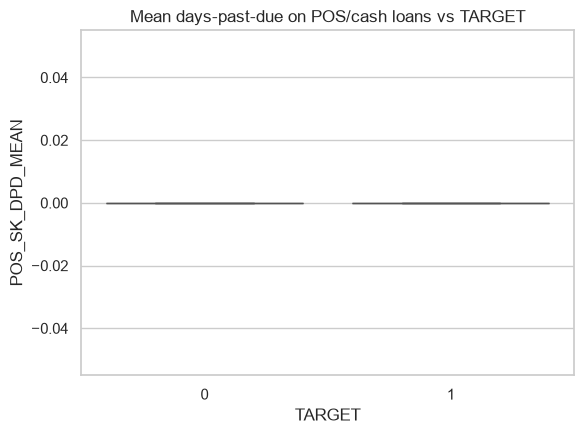

In [8]:
num_agg = {
    'SK_DPD': ['mean'],
    'CNT_INSTALMENT_FUTURE': ['mean'],
}
pos_agg = pos.groupby('SK_ID_CURR').agg(num_agg)
pos_agg.columns = ['POS_' + '_'.join(c).upper() for c in pos_agg.columns]
pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
pos_agg = pos_agg.reset_index()

merged = train[['SK_ID_CURR', 'TARGET']].merge(pos_agg, on='SK_ID_CURR', how='inner')

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=merged, x='TARGET', y='POS_SK_DPD_MEAN', ax=ax, showfliers=False)
ax.set_title('Mean days-past-due on POS/cash loans vs TARGET')
plt.tight_layout()
plt.show()


<a id='8'></a>
## 8. `aggregate_credit_card` — credit-card monthly balances

Kept: `CC_AMT_BALANCE_MEAN`, `CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN`, `CC_COUNT`.

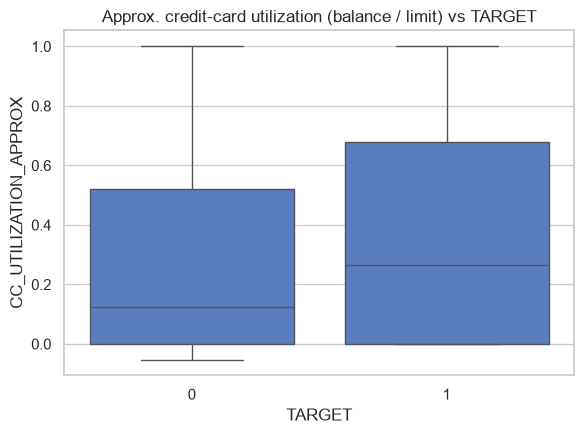

In [9]:
num_agg = {
    'AMT_BALANCE': ['mean'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['mean'],
}
cc_agg = cc.groupby('SK_ID_CURR').agg(num_agg)
cc_agg.columns = ['CC_' + '_'.join(c).upper() for c in cc_agg.columns]
cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
cc_agg = cc_agg.reset_index()

merged = train[['SK_ID_CURR', 'TARGET']].merge(cc_agg, on='SK_ID_CURR', how='inner')
merged['CC_UTILIZATION_APPROX'] = merged['CC_AMT_BALANCE_MEAN'] / merged['CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN']

fig, ax = plt.subplots(figsize=(6, 4.5))
clip = merged['CC_UTILIZATION_APPROX'].quantile(0.95)
sns.boxplot(data=merged[merged['CC_UTILIZATION_APPROX'] <= clip], x='TARGET', y='CC_UTILIZATION_APPROX', ax=ax, showfliers=False)
ax.set_title('Approx. credit-card utilization (balance / limit) vs TARGET')
plt.tight_layout()
plt.show()


<a id='9'></a>
## 9. `aggregate_installments` — instalment repayment behavior

Kept: `INSTAL_AMT_INSTALMENT_MEAN`, `INSTAL_DAYS_LATE_MEAN` (`DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT`, computed inside the function), `INSTAL_COUNT`.

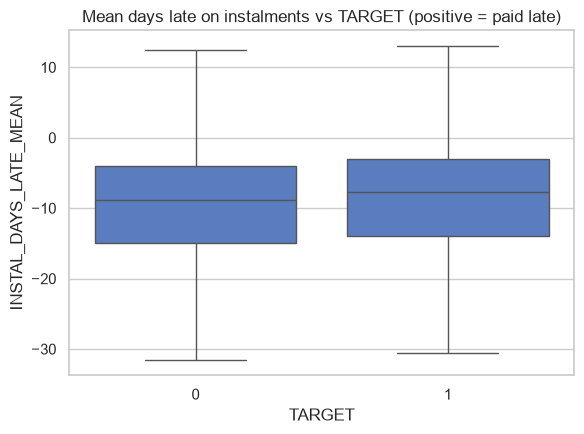

In [10]:
inst['DAYS_LATE'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']

num_agg = {
    'AMT_INSTALMENT': ['mean'],
    'DAYS_LATE': ['mean'],
}
inst_agg = inst.groupby('SK_ID_CURR').agg(num_agg)
inst_agg.columns = ['INSTAL_' + '_'.join(c).upper() for c in inst_agg.columns]
inst_agg['INSTAL_COUNT'] = inst.groupby('SK_ID_CURR').size()
inst_agg = inst_agg.reset_index()

merged = train[['SK_ID_CURR', 'TARGET']].merge(inst_agg, on='SK_ID_CURR', how='inner')

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=merged, x='TARGET', y='INSTAL_DAYS_LATE_MEAN', ax=ax, showfliers=False)
ax.set_title('Mean days late on instalments vs TARGET (positive = paid late)')
plt.tight_layout()
plt.show()


<a id='10'></a>
## 10. All simplified features together — correlation with TARGET

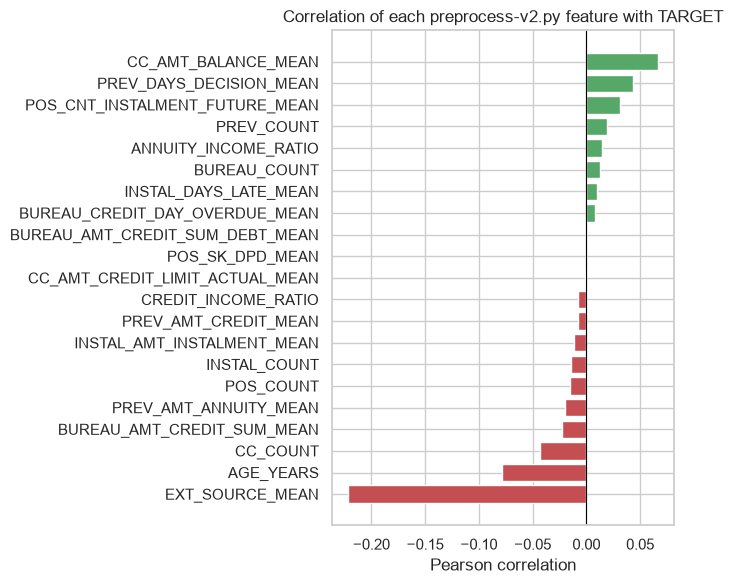

In [11]:
full = train[['SK_ID_CURR', 'TARGET'] + app_features]
for agg in (bureau_agg, prev_agg, pos_agg, cc_agg, inst_agg):
    full = full.merge(agg, on='SK_ID_CURR', how='left')

feature_cols = [c for c in full.columns if c not in ('SK_ID_CURR', 'TARGET')]
corr = full[feature_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#C44E52' if v < 0 else '#55A868' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlation of each preprocess-v2.py feature with TARGET')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()


## 11. Takeaways

- `EXT_SOURCE_MEAN` remains, by far, the strongest signal — consistent with the full pipeline in
  `preprocess.py` and with the top features reported in `results/model/feature_importance.png`.
- Bureau, previous-application, POS and instalment aggregates keep a visible (if weaker) split
  between `TARGET = 0` and `TARGET = 1`, which is expected since `preprocess-v2.py` only trims the
  *number* of stats per table, not the underlying signal.
- `preprocess-v2.py` trades feature richness for simplicity/speed: fewer columns to compute, join
  and store, at the cost of some predictive power compared to `preprocess.py`'s full feature set.
